In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Load & Split
df = pd.read_csv('../../data/noisy_inversion.csv')

# Create a mapping for your labels
label_mapping = {label: i for i, label in enumerate(df['sentiment'].unique())}
print(f"Mapping: {label_mapping}")

# Apply mapping to the whole dataframe
df['sentiment'] = df['sentiment'].map(label_mapping)

Mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


In [2]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# Run this before splitting
df['review'] = df['review'].fillna('').astype(str)

df_train_val, df_test = train_test_split(df, test_size=0.10, random_state=42, stratify=df['sentiment'])
df_train, df_val = train_test_split(df_train_val, test_size=0.1111, random_state=42, stratify=df_train_val['sentiment'])

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Train: 6586 | Val: 824 | Test: 824


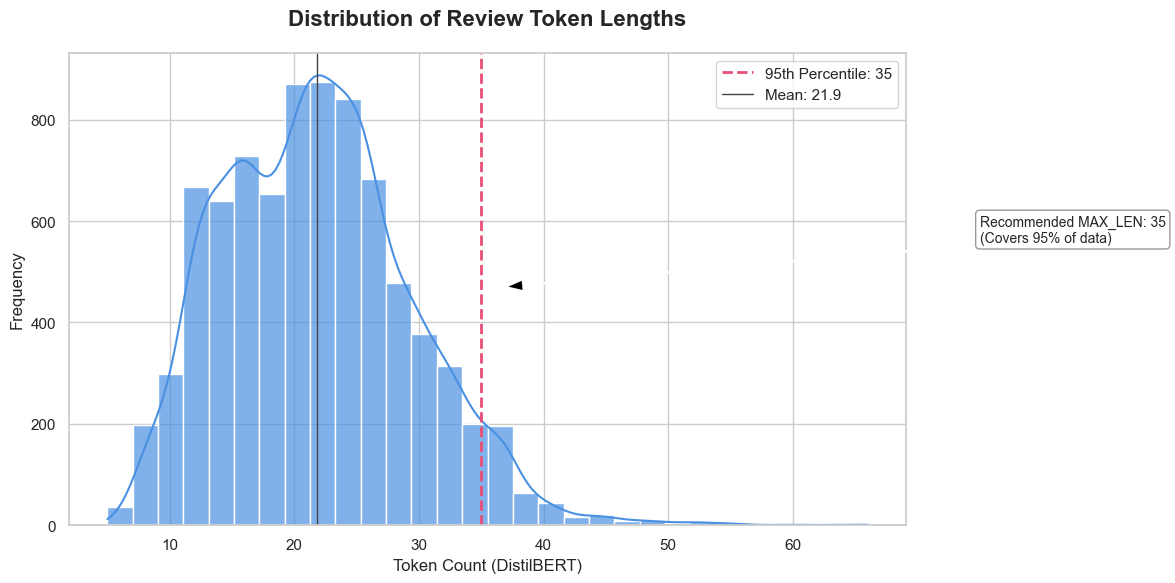

Using MAX_LEN: 35


In [3]:
from transformers import DistilBertTokenizer

# Assuming 'reviews' is your list of text strings
# and 'tokenizer' is your DistilBERT tokenizer

# Initialize the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

token_lens = []

# Iterate over the actual column values
for txt in df['review']:
    tokens = tokenizer.encode(txt, max_length=512, truncation=True)
    token_lens.append(len(tokens))

# Calculate statistics
max_len_95 = int(np.percentile(token_lens, 95))
avg_len = np.mean(token_lens)

# Set the aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. Create the distribution plot
ax = sns.histplot(token_lens, bins=30, kde=True, color='#4A90E2', edgecolor='white', alpha=0.7)

# 2. Add vertical lines for key metrics
plt.axvline(max_len_95, color='#E94E77', linestyle='--', linewidth=2, label=f'95th Percentile: {max_len_95}')
plt.axvline(avg_len, color='#444444', linestyle='-', linewidth=1, label=f'Mean: {avg_len:.1f}')

# 3. Enhance labels and titles
plt.title('Distribution of Review Token Lengths', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Token Count (DistilBERT)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# 4. Add an annotation box for the MAX_LEN logic
plt.annotate(f'Recommended MAX_LEN: {max_len_95}\n(Covers 95% of data)',
             xy=(max_len_95, ax.get_ylim()[1] * 0.5),
             xytext=(max_len_95 + 40, ax.get_ylim()[1] * 0.6),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Using MAX_LEN: {max_len_95}")

In [4]:
max_len_95 = int(np.percentile(token_lens, 95))
MAX_LEN = max_len_95

In [5]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertModel

class InverseSynthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.to_numpy()
        self.labels = labels.to_numpy()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        encoding = self.tokenizer.encode_plus(
            str(self.texts[item]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

class DistilBertClassifier(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(self.distilbert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]
        return self.out(self.drop(pooled_output))

In [6]:
from torch.optim import AdamW


# Create DataLoaders
train_ds = InverseSynthDataset(df_train['review'], df_train['sentiment'], tokenizer, MAX_LEN)
val_ds = InverseSynthDataset(df_val['review'], df_val['sentiment'], tokenizer, MAX_LEN)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)

# Initialize Model & Weights
weights = compute_class_weight('balanced', classes=np.unique(df_train['sentiment']), y=df_train['sentiment'])
weights = torch.tensor(weights, dtype=torch.float).to(device)

model = DistilBertClassifier(n_classes=3).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss(weight=weights)

# Training Loop
EPOCHS = 3
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch + 1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/3 | Loss: 0.2644
Epoch 2/3 | Loss: 0.0590
Epoch 3/3 | Loss: 0.0281


In [7]:
# 1. Prepare Test DataLoader
test_ds = InverseSynthDataset(df_test['review'], df_test['sentiment'], tokenizer, MAX_LEN)
test_loader = DataLoader(test_ds, batch_size=16)

# 2. Evaluation
model.eval()
predictions = []
real_values = []
review_texts = df_test['review'].tolist()

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask)
        _, preds = torch.max(outputs, dim=1)

        predictions.extend(preds.cpu().tolist())
        real_values.extend(labels.cpu().tolist())

# 3. Create a Comparison DataFrame
# Inverse the mapping to see actual names (e.g., 0 -> 'negative')
inv_map = {v: k for k, v in label_mapping.items()}

results_df = pd.DataFrame({
    'Review Text': review_texts,
    'Actual Label': [inv_map[v] for v in real_values],
    'Predicted Label': [inv_map[p] for p in predictions]
})

# Add a column to easily see where the model was wrong
results_df['Correct'] = results_df['Actual Label'] == results_df['Predicted Label']

# Display the first 10 rows
import IPython.display as display
display.display(results_df.head(10))

,Review Text,Actual Label,Predicted Label,Correct
0,annoyed. so I'm money! of waste a What arrival...,negative,negative,True
1,spending. tracking for charts helpful and inte...,positive,positive,True
2,quality. the with disappointed so I'm uses. fe...,negative,negative,True
3,"chaotic. bit a felt it but activities, few a e...",neutral,neutral,True
4,better. be could camera the but do to it need ...,neutral,neutral,True
5,"to. get to easy but center, city the from far ...",neutral,neutral,True
6,"too. handle, Ergonomic squishing. without loav...",positive,positive,True
7,furious! I'm it. with playing kid my of minute...,negative,negative,True
8,carry. to easy and compact is It light. bright...,neutral,neutral,True
9,frame. its challenge may storm heavy a but com...,neutral,neutral,True


In [8]:
# Show instances where the model failed
errors = results_df[results_df['Correct'] == False]
print(f"Total Errors: {len(errors)} out of {len(results_df)}")
display.display(errors.head(10))

Total Errors: 50 out of 824


,Review Text,Actual Label,Predicted Label,Correct
14,"potency. affecting opened, once like I'd than ...",negative,positive,False
23,afterward. moisturizer required and use first ...,negative,neutral,False
26,yard. the of end far the reach to stretches ho...,neutral,positive,False
31,cleaning. deep for power suction lacks cleaner...,negative,neutral,False
39,outages. during unreliable was backup Battery ...,negative,neutral,False
40,tilted. when leaks bottle water DEF The,negative,neutral,False
53,foods. of variety a cooks It clean. to easy is...,neutral,positive,False
63,price. the for wasteful was and plan dinner ou...,negative,positive,False
72,through. halfway interest lost I tedious; and ...,negative,positive,False
78,issues. shutter rolling noticeable had footage...,negative,positive,False



### Classification Report ###
              precision    recall  f1-score   support

    negative       1.00      0.87      0.93       267
     neutral       0.94      0.94      0.94       246
    positive       0.90      1.00      0.95       311

    accuracy                           0.94       824
   macro avg       0.95      0.94      0.94       824
weighted avg       0.94      0.94      0.94       824



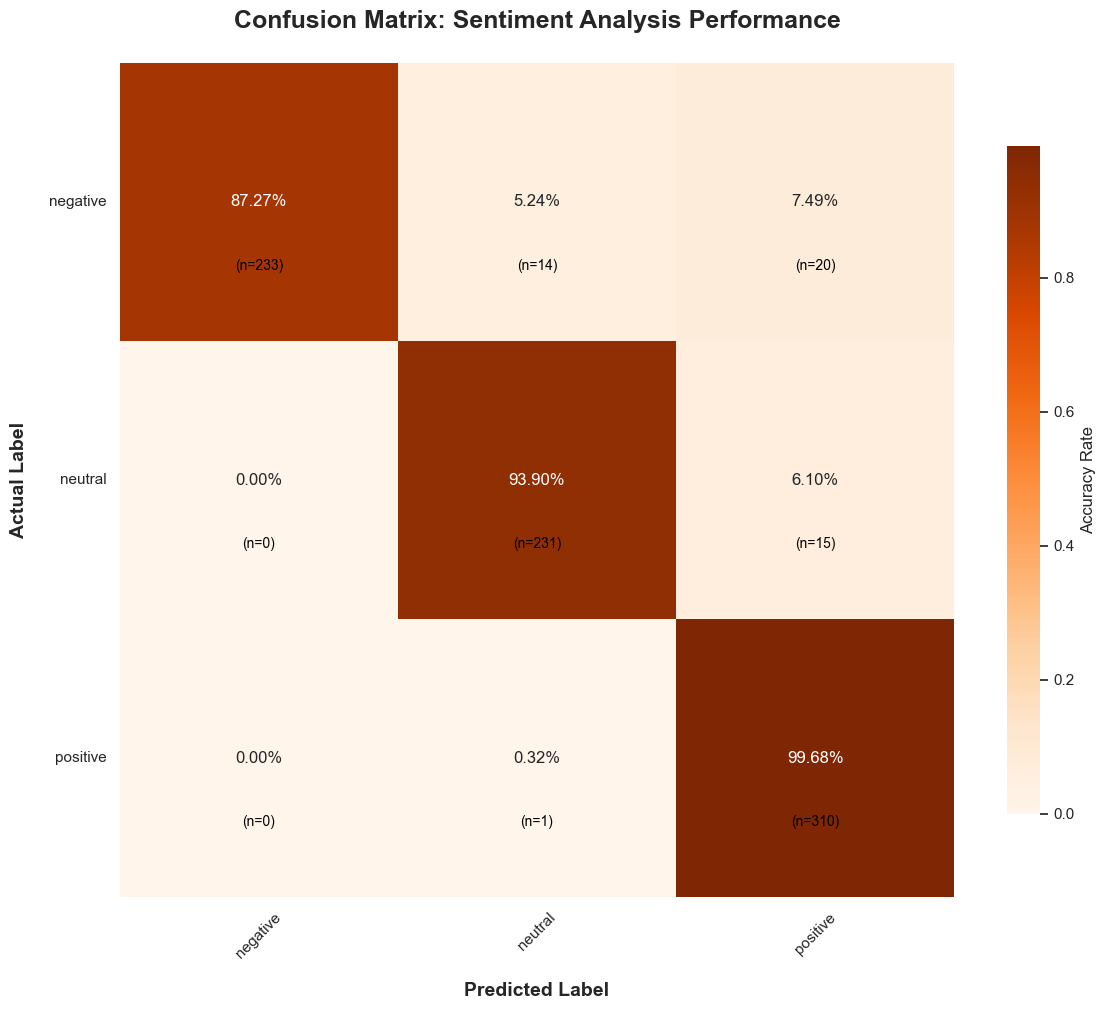

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
# Prepare Target Names

target_names = [str(inv_map[i]) for i in sorted(inv_map.keys())]

# Generate the Classification Report
print("\n### Classification Report ###")
print(classification_report(real_values, predictions, target_names=target_names))

# Create Confusion Matrices (Raw and Normalized)
cm = confusion_matrix(real_values, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Advanced Visualization
plt.figure(figsize=(12, 10))
sns.set_theme(style="white")

# Plotting Normalized Heatmap for better insight into class accuracy
ax = sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2%',
    cmap='Oranges',
    xticklabels=target_names,
    yticklabels=target_names,
    square=True,
    cbar_kws={'shrink': .8, 'label': 'Accuracy Rate'}
)

# Add the raw counts inside the cells as well
for i in range(len(target_names)):
    for j in range(len(target_names)):
        ax.text(j+0.5, i+0.7, f'\n(n={cm[i, j]})',
                ha='center', va='center', color='black', fontsize=10)

# Enhance labels and aesthetics
plt.title('Confusion Matrix: Sentiment Analysis Performance', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel('Actual Label', fontsize=14, fontweight='bold', labelpad=15)

# Adjust tick rotation for readability
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [10]:
import torch
import os

#save_directory = "./models/inver_distilbert_model"
#os.makedirs(save_directory, exist_ok=True)

# Save the custom model weights
#torch.save(model.state_dict(), os.path.join(save_directory, "model_weights.pth"))

# Save the tokenizer (this works fine as is)
#tokenizer.save_pretrained(save_directory)

# Save the config (optional but helpful for class initialization)
#model.distilbert.config.save_pretrained(save_directory)

#print("Model saved successfully!")


Model saved successfully!


In [11]:
from lime.lime_text import LimeTextExplainer
import torch.nn.functional as F

def predictor(texts):
    model.eval()
    encoded = tokenizer(texts, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt')
    input_ids = encoded['input_ids'].to('mps')
    attention_mask = encoded['attention_mask'].to('mps')

    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = F.softmax(logits, dim=1)
    return probs.cpu().numpy()

explainer = LimeTextExplainer(class_names=['Negative', 'Neutral', 'Positive'])

# Explain a single instance
str_to_explain = ",money. of waste Total second. every regretted I snoozefest. complete a was movie The"
# Explain a single instance for all labels
exp = explainer.explain_instance(
    str_to_explain,
    predictor,
    num_features=6,
    labels=(0, 1, 2)  # This tells LIME to explain all three classes
)

# Show the explanation for a specific label, or the whole thing
exp.show_in_notebook()

--- Stability Metrics for Sample ---
Variable Stability Index (VSI): 0.8576
Coefficient Stability Index (CSI): 0.9988


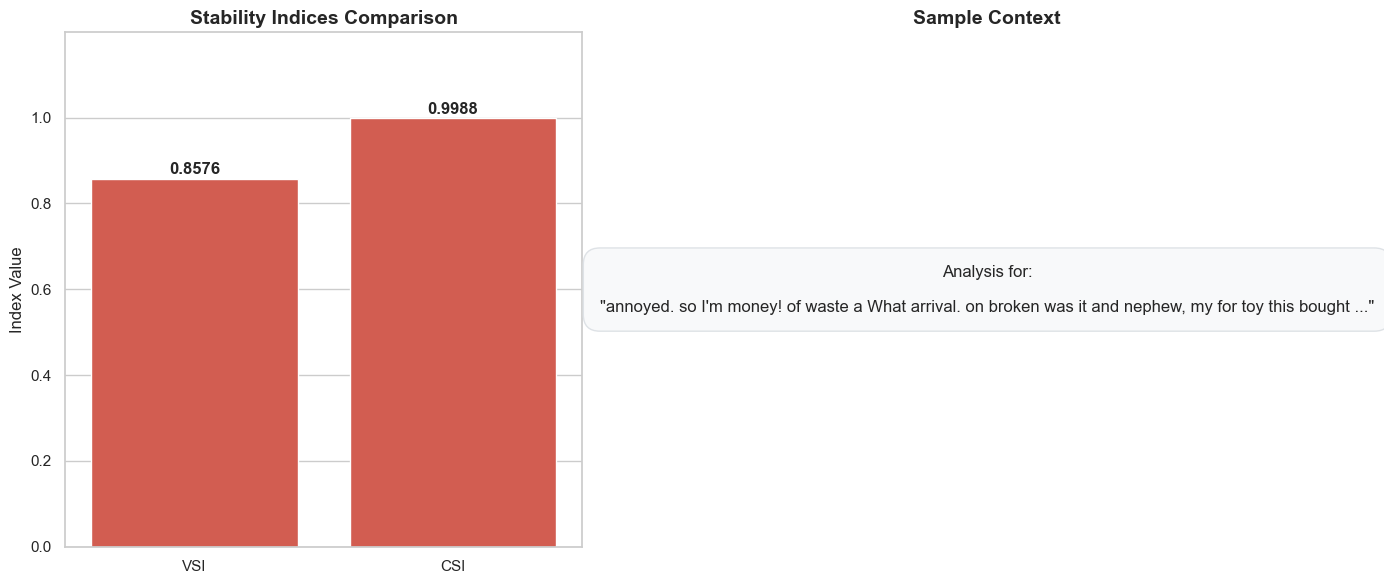

In [13]:
def predict_proba(texts):
    model.eval()
    # Tokenize the input texts
    encodings = tokenizer(
        texts,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encodings['input_ids'].to(device)
    attention_mask = encodings['attention_mask'].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        # Convert logits to probabilities using Softmax
        probs = torch.nn.functional.softmax(logits, dim=1)

    return probs.cpu().detach().numpy()


from lime.lime_text import LimeTextExplainer

# class_names should match your label_mapping order (0, 1, 2)
class_names = [inv_map[i] for i in range(len(inv_map))]
explainer = LimeTextExplainer(class_names=class_names)


def calculate_stability_indices(explainer, text_instance, predict_fn, num_runs=5):
    all_features = []
    all_weights = []

    for _ in range(num_runs):
        # explain_instance for text returns word importance
        exp = explainer.explain_instance(text_instance, predict_fn, num_features=10)

        # Get the explanation for the predicted class
        # exp.available_labels()[0] gets the top predicted class
        pred_label = exp.available_labels()[0]
        dict_exp = dict(exp.as_list(label=pred_label))

        all_features.append(set(dict_exp.keys()))
        all_weights.append(dict_exp)

    # --- VSI (Variable Stability Index) ---
    jaccard_sims = []
    for i in range(num_runs):
        for j in range(i + 1, num_runs):
            set_i, set_j = all_features[i], all_features[j]
            intersection = len(set_i.intersection(set_j))
            union = len(set_i.union(set_j))
            jaccard_sims.append(intersection / union if union > 0 else 1)

    vsi = np.mean(jaccard_sims)

    # --- CSI (Coefficient Stability Index) ---
    unique_features = set().union(*all_features)
    weight_variances = []

    for feat in unique_features:
        weights_for_feat = [run[feat] for run in all_weights if feat in run]
        if len(weights_for_feat) > 1:
            weight_variances.append(np.std(weights_for_feat))

    csi = 1 - np.mean(weight_variances) if weight_variances else 1.0

    return vsi, csi


# Pick a sample from the test set
sample_text = df_test['review'].iloc[0]

vsi, csi = calculate_stability_indices(explainer, sample_text, predict_proba)

print(f"--- Stability Metrics for Sample ---")
print(f"Variable Stability Index (VSI): {vsi:.4f}")
print(f"Coefficient Stability Index (CSI): {csi:.4f}")


def visualize_stability(vsi, csi, sample_text):
    # Setting the aesthetic style
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # 1. Gauge/Indicator Plot for VSI & CSI
    metrics = {'VSI': vsi, 'CSI': csi}
    names = list(metrics.keys())
    values = list(metrics.values())

    # Color mapping (Lower is usually better for instability, but check your specific index definition)
    # Assuming lower = more stable
    colors = ['#2ecc71' if v < 0.15 else '#f1c40f' if v < 0.3 else '#e74c3c' for v in values]

    sns.barplot(x=names, y=values, palette=colors, ax=ax1, hue=names, legend=False)
    ax1.set_title("Stability Indices Comparison", fontsize=14, fontweight='bold')
    ax1.set_ylim(0, max(max(values) * 1.2, 0.5))
    ax1.set_ylabel("Index Value")

    # Annotate bars
    for i, v in enumerate(values):
        ax1.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

    # 2. Text Content Context (Optional Visualization)
    # This creates a "Heatmap-lite" view of the sample text
    # to remind you which text produced these scores
    ax2.axis('off')
    ax2.set_title("Sample Context", fontsize=14, fontweight='bold')
    wrapped_text = (sample_text[:100] + '...') if len(sample_text) > 100 else sample_text
    ax2.text(0.5, 0.5, f"Analysis for:\n\n\"{wrapped_text}\"",
             ha='center', va='center', wrap=True, fontsize=12,
             bbox=dict(boxstyle="round,pad=1", fc='#f8f9fa', ec='#dee2e6'))

    plt.tight_layout()
    plt.show()


# Usage
visualize_stability(vsi, csi, sample_text)